# Week 4 Day 1 Lab


Generally useful functions:
```python
df.head()
df.tail()
df.info()
df.describe()
df.shape
df.columns
df.isnull().sum()
df.duplicated().sum()
df.corr(numeric_only=True)
df.value_counts()
```

Useful plotting functions:

```python
plt.hist()
plt.scatter()
plt.bar()
plt.boxplot()
df.plot()
```

where `df` is a `pandas.DataFrame` object and `plt` is the `matplotlib.pyplot` library


### Problem 1: Data Selection

Choose **one** of the following datasets on GitHub:
- Iris Dataset
- Titanic Dataset


Titanic Dataset

### Problem 2: Loading the Data
1. Load the dataset into a Pandas DataFrame.
2. Display the first five rows.
3. Display the last five rows.

In [4]:
import pandas as pd
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
import pandas as pd
df = pd.read_csv("titanic.csv")
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Problem 3: Inspect Data
1. How many rows are in the dataset?
2. How many columns are in the dataset?
3. What are the column names?
4. What data type is each column?
5. Are there any missing values?
6. Are there any duplicate rows?

In [6]:
print("shape of dataset:", df.shape)
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nMissing values in each column:")
print(df.isnull().sum())
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


shape of dataset: (891, 12)
number of rows: 891
number of columns: 12

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Number of duplicate rows:
0


### Problem 4: Summary Statistics
For each numerical column, compute the following:
- Mean
- Median
- Mode
- Minimum
- Maximum
- Standard deviation


1. Which variable has the greatest variation?
2. Which variable has the smallest variation?


In [10]:
num_df = df.select_dtypes(include = 'number')
summary = num_df.agg(['mean', 'median', 'min', 'max', 'std'])
summary.loc['mode'] = num_df.mode().iloc[0]
print(summary.T)

                   mean    median   min       max         std   mode
PassengerId  446.000000  446.0000  1.00  891.0000  257.353842   1.00
Survived       0.383838    0.0000  0.00    1.0000    0.486592   0.00
Pclass         2.308642    3.0000  1.00    3.0000    0.836071   3.00
Age           29.699118   28.0000  0.42   80.0000   14.526497  24.00
SibSp          0.523008    0.0000  0.00    8.0000    1.102743   0.00
Parch          0.381594    0.0000  0.00    6.0000    0.806057   0.00
Fare          32.204208   14.4542  0.00  512.3292   49.693429   8.05


### Problem 5: Visualization
1. Choose a numerical column from your dataset and:
    - Plot the corresponding histogram. 
        - What does the distribution look like?
        - Is it symmetric or skewed?
    - Plot the corresponding box plot.
        - Are there any outliers?
        - Explain what you observe.
2. Choose one categorical column from your dataset and:
    - Plot the corresponding bar chart.
        - Which category occurs most frequently?
        - Which occurs least frequently?


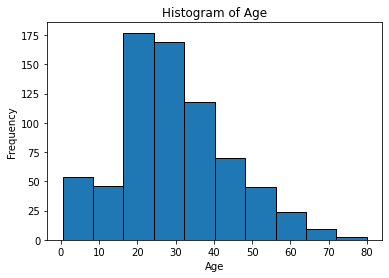

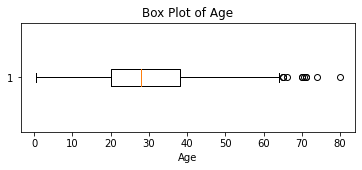

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
plt.figure(figsize=(6,2))
plt.boxplot(df["Age"].dropna(), vert=False)
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

1) Histogram: skewed towards ages 20-30. Boxplot: few outliers above the age 60

In [14]:
import matplotlib.pyplot as plt
counts = df["Gender"].value_counts()
counts.plot(kind="bar", color="blue", edgecolor="black")
plt.title("Bar Chart of Gender")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.show()

KeyError: 'Gender'